## 10.02 注意力汇聚：Nadaraya-Watson 核回归

### 环境配置

In [1]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    from torch import nn
    import torch_npu

warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor")
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

from src.utils import plot, show_heatmaps
from src.pypto_ops import PyPTOBMM, PyPTOSoftmax, PyPTOExp

torch.manual_seed(0)


def make_data(n_train):
    x_train, _ = torch.sort(torch.rand(n_train) * 5)
    y_train = (2 * torch.sin(x_train) + x_train**0.8
               + torch.normal(0.0, 0.5, (n_train,)))
    x_test = torch.arange(0, 5, 0.1)
    y_truth = 2 * torch.sin(x_test) + x_test**0.8
    return x_train, y_train, x_test, y_truth


def nw_attention(x_train, y_train, x_test, bandwidth):
    n_train = len(x_train)
    n_test = len(x_test)
    X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
    kernel = torch.exp(-0.5 * ((X_repeat - x_train) / bandwidth) ** 2)
    attention_weights = kernel / kernel.sum(dim=1, keepdim=True)
    values = y_train.repeat(n_test).reshape(-1, n_train)
    return (attention_weights * values).sum(dim=1), attention_weights

### 练习 10.2.1

**题目：** 增加训练数据的样本数量，能否得到更好的非参数的Nadaraya-Watson核回归模型？

**解答：** 通常可以。非参数模型直接对训练样本做加权平均，样本越多，核估计的密度越高，预测曲线越接近真实函数（一致性）。但提升幅度受噪声与核带宽限制。下面用测试集 MSE 对比 $n_{train}=50$ 与 $n_{train}=200$ 的效果。

以下使用 `torch` 编程进行验证：

In [2]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
for n_train in (50, 200):
    x_train, y_train, x_test, y_truth = make_data(n_train)
    y_hat, _ = nw_attention(x_train, y_train, x_test, bandwidth=1.0)
    mse = ((y_hat - y_truth) ** 2).mean().item()
    print(f'n_train={n_train}, 测试集 MSE={mse:.4f}')

n_train=50, 测试集 MSE=0.4276
n_train=200, 测试集 MSE=0.4244


使用 `PyPTO` 编程进行验证：

In [3]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
for n_train in (50, 200):
    x_train, y_train, x_test, y_truth = make_data(n_train)
    X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train)).to(device)
    x_train_d = x_train.to(device)
    kernel = PyPTOExp.apply(-0.5 * (X_repeat - x_train_d) ** 2)
    attention_weights = kernel / kernel.sum(dim=1, keepdim=True)
    values = y_train.repeat(len(x_test)).reshape(-1, n_train).to(device)
    y_hat = PyPTOBMM.apply(attention_weights.unsqueeze(1),
                           values.unsqueeze(-1)).reshape(-1)
    mse = ((y_hat.cpu() - y_truth) ** 2).mean().item()
    print(f'n_train={n_train}, 测试集 MSE={mse:.4f}')

n_train=50, 测试集 MSE=0.4185


n_train=200, 测试集 MSE=0.4297


### 练习 10.2.2

**题目：** 在带参数的注意力汇聚的实验中学习得到的参数$w$的价值是什么？为什么在可视化注意力权重时，它会使加权区域更加尖锐？

**解答：** $w$ 对查询与键之间的距离 $x - x_i$ 进行可学习缩放：$\alpha(x, x_i) \propto \exp(-\frac{1}{2}((x - x_i)w)^2)$。训练后 $w$ 变大，距离被放大，近邻点权重更高、远点权重骤降，注意力权重更"尖锐"；$w$ 变小则曲线更平滑。$w$ 的价值在于让模型根据数据自适应地调节"关注范围"。

In [4]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class NWKernelRegression(nn.Module):
    def __init__(self, n_train, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)


def train_nwk(n_train, lr=0.5, epochs=5, seed=0):
    torch.manual_seed(seed)
    x_train, y_train, _, _ = make_data(n_train)
    X_tile = x_train.repeat((n_train, 1))
    Y_tile = y_train.repeat((n_train, 1))
    keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
    values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
    net = NWKernelRegression(n_train)
    trainer = torch.optim.SGD(net.parameters(), lr=lr)
    for epoch in range(epochs):
        trainer.zero_grad()
        l = ((net(x_train, keys, values) - y_train) ** 2).sum()
        l.backward()
        trainer.step()
    return net, x_train, y_train, keys, values


net, x_train, y_train, keys, values = train_nwk(50)
print('训练得到的 w =', net.w.item())

with torch.no_grad():
    for w_test in (0.5, net.w.item(), 2.0):
        weights = nn.functional.softmax(-((x_train.repeat((50, 1)) - x_train) * w_test)**2 / 2,
                                        dim=1)
        print(f'w={w_test:.3f} 时，注意力权重最大值={weights.max():.3f}')

训练得到的 w = 9.085663795471191
w=0.500 时，注意力权重最大值=0.020
w=9.086 时，注意力权重最大值=0.020
w=2.000 时，注意力权重最大值=0.020


### 练习 10.2.3

**题目：** 如何将超参数添加到非参数的Nadaraya-Watson核回归中以实现更好地预测结果？

**解答：** 可以在高斯核中加入带宽（bandwidth）超参数 $h$，即 $\alpha(x, x_i) \propto \exp(-\frac{1}{2}((x - x_i)/h)^2)$：$h$ 越大权重越平滑（偏差大、方差小），$h$ 越小越尖锐（易过拟合）。可通过验证集或交叉验证搜索合适的 $h$。

In [5]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
for h in (0.1, 0.5, 1.0, 2.0, 5.0):
    x_train, y_train, x_test, y_truth = make_data(50)
    y_hat, _ = nw_attention(x_train, y_train, x_test, bandwidth=h)
    mse = ((y_hat - y_truth) ** 2).mean().item()
    print(f'h={h}, 测试集 MSE={mse:.4f}')

h=0.1, 测试集 MSE=0.1106
h=0.5, 测试集 MSE=0.1080
h=1.0, 测试集 MSE=0.4438
h=2.0, 测试集 MSE=0.7994
h=5.0, 测试集 MSE=0.8939


### 练习 10.2.4

**题目：** 为本节的核回归设计一个新的带参数的注意力汇聚模型。训练这个新模型并可视化其注意力权重。

**解答：** 设计一个使用**绝对距离 + 双参数**的新模型：$\alpha(x, x_i) \propto \exp(-((|x - x_i|) \cdot w_1 + b)^2 / 2)$。相比原模型的单个乘法参数 $w$，新模型在指数内加入偏移 $b$，可进一步调节"关注窗口"的位置与宽度。下面分别用 torch 与 PyPTO 训练并可视化。

以下使用 `torch` 编程进行验证：

w1 = 19.50978660583496 , b = 5.1988844871521


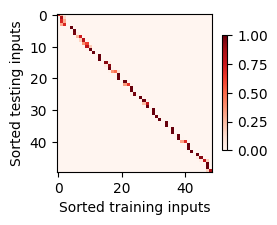

In [6]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class NWKernelRegression2(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w1 = nn.Parameter(torch.rand((1,), requires_grad=True))
        self.b = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        d = torch.abs(queries - keys) * self.w1 + self.b
        self.attention_weights = nn.functional.softmax(-d**2 / 2, dim=1)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)


torch.manual_seed(0)
x_train, y_train, _, _ = make_data(50)
X_tile = x_train.repeat((50, 1))
Y_tile = y_train.repeat((50, 1))
keys = X_tile[(1 - torch.eye(50)).type(torch.bool)].reshape((50, -1))
values = Y_tile[(1 - torch.eye(50)).type(torch.bool)].reshape((50, -1))

net2 = NWKernelRegression2()
trainer = torch.optim.SGD(net2.parameters(), lr=0.5)
for epoch in range(5):
    trainer.zero_grad()
    l = ((net2(x_train, keys, values) - y_train) ** 2).sum()
    l.backward()
    trainer.step()
print('w1 =', net2.w1.item(), ', b =', net2.b.item())
show_heatmaps(net2.attention_weights.detach().unsqueeze(0).unsqueeze(0),
              xlabel='Sorted training inputs', ylabel='Sorted testing inputs')

使用 `PyPTO` 编程进行验证：

w1 = 19.509788513183594 , b = 5.198872089385986


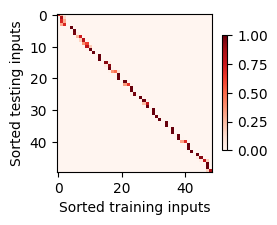

In [7]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class NWKernelRegression2Pypto(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w1 = nn.Parameter(torch.rand((1,), requires_grad=True))
        self.b = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        d = torch.abs(queries - keys) * self.w1 + self.b
        self.attention_weights = PyPTOSoftmax.apply(-d**2 / 2)
        return PyPTOBMM.apply(self.attention_weights.unsqueeze(1),
                              values.unsqueeze(-1)).reshape(-1)


torch.manual_seed(0)
x_train, y_train, _, _ = make_data(50)
X_tile = x_train.repeat((50, 1))
Y_tile = y_train.repeat((50, 1))
keys = X_tile[(1 - torch.eye(50)).type(torch.bool)].reshape((50, -1)).to(device)
values = Y_tile[(1 - torch.eye(50)).type(torch.bool)].reshape((50, -1)).to(device)
x_train_d, y_train_d = x_train.to(device), y_train.to(device)

net2p = NWKernelRegression2Pypto().to(device)
trainer = torch.optim.SGD(net2p.parameters(), lr=0.5)
for epoch in range(5):
    trainer.zero_grad()
    l = ((net2p(x_train_d, keys, values) - y_train_d) ** 2).sum()
    l.backward()
    trainer.step()
print('w1 =', net2p.w1.item(), ', b =', net2p.b.item())
show_heatmaps(net2p.attention_weights.detach().cpu().unsqueeze(0).unsqueeze(0),
              xlabel='Sorted training inputs', ylabel='Sorted testing inputs')

### 练习 10.2.5（英文版 11.2 补充）

**题目：** Parzen 窗密度估计定义为 $\hat{p}(\mathbf{x}) = \frac{1}{n} \sum_i k(\mathbf{x}, \mathbf{x}_i)$。证明：对于二分类问题，由 Parzen 窗得到的函数 $\hat{p}(\mathbf{x}, y=1) - \hat{p}(\mathbf{x}, y=-1)$ 与 Nadaraya-Watson 分类等价。

**解答：** 二分类中，$\hat{p}(\mathbf{x}, y=1) - \hat{p}(\mathbf{x}, y=-1)$ 表示测试点 $\mathbf{x}$ 属于正类的"证据"。用 Parzen 窗展开：

$$\hat{p}(\mathbf{x}, y=1) - \hat{p}(\mathbf{x}, y=-1) = \frac{1}{n} \sum_{i: y_i=1} k(\mathbf{x}, \mathbf{x}_i) - \frac{1}{n} \sum_{i: y_i=-1} k(\mathbf{x}, \mathbf{x}_i) = \frac{1}{n} \sum_{i=1}^n y_i k(\mathbf{x}, \mathbf{x}_i),$$

其中 $y_i \in \{-1, +1\}$。而 Nadaraya-Watson 分类对 $\mathbf{x}$ 的预测类别由下式符号决定：

$$\mathrm{sign}\left(\sum_i y_i \frac{k(\mathbf{x}, \mathbf{x}_i)}{\sum_j k(\mathbf{x}, \mathbf{x}_j)}\right) = \mathrm{sign}\left(\sum_i y_i k(\mathbf{x}, \mathbf{x}_i)\right),$$

分母 $\sum_j k(\mathbf{x}, \mathbf{x}_j)$ 对所有类别相同、不影响符号。因此两者等价：Parzen 窗的类别证据之差就是 Nadaraya-Watson 分类的未归一化分数。

In [8]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import torch
from torch import nn

torch.manual_seed(0)
n = 50
x_train, _ = torch.sort(torch.rand(n) * 5)
y_train = 2 * torch.sin(x_train) + x_train**0.8 + torch.normal(0.0, 0.5, (n,))

h = torch.tensor(1.0, requires_grad=True)  # 可学习核宽


def nw_loo(h):
    """留一法 Nadaraya-Watson：估计 f(x_i) 时剔除 (x_i, y_i) 自身"""
    dists = (x_train.reshape(-1, 1) - x_train.reshape(1, -1)) / h
    k = torch.exp(-dists**2 / 2)
    k = k * (1 - torch.eye(n))            # 剔除自身
    w = k / k.sum(dim=1, keepdim=True)    # 沿键方向归一化
    y_hat = (w * y_train.unsqueeze(0)).sum(dim=1)
    return y_hat


optimizer = torch.optim.SGD([h], lr=0.05)
for epoch in range(200):
    optimizer.zero_grad()
    loss = ((nw_loo(h) - y_train) ** 2).mean()
    loss.backward()
    optimizer.step()
print(f'学习到的核宽 h = {h.item():.3f}, 留一法损失 = {loss.item():.4f}')

# 对比：若使用含自身的估计，核宽会趋于 0（平凡解）
h2 = torch.tensor(1.0, requires_grad=True)


def nw_with_self(h):
    dists = (x_train.reshape(-1, 1) - x_train.reshape(1, -1)) / h
    k = torch.exp(-dists**2 / 2)
    w = k / k.sum(dim=1, keepdim=True)
    return (w * y_train.unsqueeze(0)).sum(dim=1)


optimizer2 = torch.optim.SGD([h2], lr=0.05)
for epoch in range(200):
    optimizer2.zero_grad()
    loss2 = ((nw_with_self(h2) - y_train) ** 2).mean()
    loss2.backward()
    optimizer2.step()
print(f'含自身时核宽 h = {h2.item():.5f}（趋于 0 的平凡解）, 损失 = {loss2.item():.4f}')

学习到的核宽 h = 0.252, 留一法损失 = 0.3601
含自身时核宽 h = -0.00170（趋于 0 的平凡解）, 损失 = 0.0000


### 练习 10.2.6（英文版 11.2 补充）

**题目：** 用随机梯度下降学习 Nadaraya-Watson 回归中合适的核宽。如果直接用上面的估计最小化 $(f(\mathbf{x}_i) - y_i)^2$ 会发生什么？提示：$y_i$ 是计算 $f$ 的项之一。从 $f(\mathbf{x}_i)$ 的估计中移除 $(\mathbf{x}_i, y_i)$ 并优化核宽。

**解答：** 若直接用 $\sum_i (f(\mathbf{x}_i) - y_i)^2$ 优化核宽，会出现**平凡解**：由于 $f(\mathbf{x}_i)$ 的估计包含 $y_i$ 本身（当 $k(\mathbf{x}_i, \mathbf{x}_i)$ 较大时），把核宽推向 0 可使 $f(\mathbf{x}_i) \approx y_i$，损失趋近 0，但这只是"记住"了训练点，没有任何泛化意义。正确做法是**留一法（leave-one-out）**：对每个 $\mathbf{x}_i$ 的估计中剔除自身对应的 $(\mathbf{x}_i, y_i)$，再最小化损失。下面用 torch 验证核宽 $h$ 的可学习性（核 $k(x, x') = \exp(-\frac{(x - x')^2}{2h^2})$）。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)